In [1]:
import os

import numpy as np
import prettytable as pt
import pandas as pd
from scipy.optimize import curve_fit
from scipy.integrate import quad

import hist
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
from scipy.integrate import trapezoid

# Workspace packages
from HHtobbyy.event_discrimination.DFDataset import DFDataset
from HHtobbyy.workspace_utils import match_sample
from HHtobbyy.event_discrimination.models import map_model_to_Model
from HHtobbyy.event_discrimination.evaluation import transform_preds_func


dfdataset_config = "/eos/uscms/store/group/lpcdihiggsboost/tsievert/HiggsDNA_parquet/DFDatasets/v2/2224_catWP_VBFHH_2026-05-10_20-52-04/dataset_config.json"
dfdataset = DFDataset(dfdataset_config)
model, model_config = "MLP", {"output_dirpath": "/uscms/home/tsievert/nobackup/XHYbbgg/Model_Outputs/MLP/vNew_VBFHH_5fold_2224/2026-05-10_20-52-04"}
model = map_model_to_Model(model)(dfdataset, model_config)

cmslpcgpu3.fnal.gov      Tue May 12 08:02:56 2026  555.42.06
[0] Tesla P100-PCIE-12GB | 40°C,   1 % |     0 / 12288 MB |


In [2]:
MCres = dfdataset.get_all_test(regex=[sampl for sampl in ['ttH', 'bbH', 'VH', 'W*HToGG', 'ZHToGG', 'GluGluHToGG', 'VBFHToGG']])
pd.unique(MCres['AUX_sample_name'])

<ArrowStringArray>
['GluGluHToGG',    'VBFHToGG',      'VHToGG',     'bbHToGG',     'ttHToGG',
     'WmHToGG',     'WpHToGG',      'ZHToGG']
Length: 8, dtype: str

In [3]:
output_names, func, cutdir = transform_preds_func(dfdataset.class_sample_map.keys(), '3D')

In [4]:
import copy
cuts2224 = [0.0075, 0.003, 0.0005]
res_output = func(copy.deepcopy(MCres.loc[:, ['AUX_DggFHH', 'AUX_DttHbbHVH', 'AUX_DggFHVBFH', 'AUX_DnonRes', 'AUX_DVBFHH']].to_numpy()))
mask = np.logical_and(
    np.logical_and(res_output[:, 0] < cuts2224[0], res_output[:, 1] < cuts2224[1]),
    res_output[:, 2] < cuts2224[2]
)
mass_mask = np.logical_and(
    mask, np.logical_and(MCres['AUX_nonResReg_vbfpair_dijet_mass_DNNreg'].gt(80), MCres['AUX_nonResReg_vbfpair_dijet_mass_DNNreg'].lt(190))
)
for sample_name in pd.unique(MCres['AUX_sample_name']):
    sample_mask = MCres['AUX_sample_name'].eq(sample_name)
    print('-'*60, '\n', sample_name)
    print(f"Baseline {sample_name} yield in best category optimized on 22-24 {MCres.loc[np.logical_and(mask, sample_mask), 'AUX_eventWeight'].sum()}")
    print(f"Baseline {sample_name} yield in best category optimized on 22-24 {MCres.loc[np.logical_and(mass_mask, sample_mask), 'AUX_eventWeight'].sum()}")

/uscms_data/d3/tsievert/XHYbbgg/HHtobbyy/src/HHtobbyy/event_discrimination/evaluation/evaluation_utils.py:92: RuntimeWarning: divide by zero encountered in divide
  b_preds = multibdt_output[:, 2] / (1 - a_preds)
/uscms_data/d3/tsievert/XHYbbgg/HHtobbyy/src/HHtobbyy/event_discrimination/evaluation/evaluation_utils.py:93: RuntimeWarning: invalid value encountered in multiply
  c_preds = multibdt_output[:, 3] / ( (1 - a_preds) * (1 - b_preds) )


------------------------------------------------------------ 
 GluGluHToGG
Baseline GluGluHToGG yield in best category optimized on 22-24 0.10113589530697577
Baseline GluGluHToGG yield in best category optimized on 22-24 0.10113589530697577
------------------------------------------------------------ 
 VBFHToGG
Baseline VBFHToGG yield in best category optimized on 22-24 0.018999952509388452
Baseline VBFHToGG yield in best category optimized on 22-24 0.018999952509388452
------------------------------------------------------------ 
 VHToGG
Baseline VHToGG yield in best category optimized on 22-24 0.007664624730234974
Baseline VHToGG yield in best category optimized on 22-24 0.007029168948260492
------------------------------------------------------------ 
 bbHToGG
Baseline bbHToGG yield in best category optimized on 22-24 0.005219101562764625
Baseline bbHToGG yield in best category optimized on 22-24 0.005219101562764625
------------------------------------------------------------ 
 ttH

In [3]:
plot_labels = []
plot_numbers = []
for class_label, pred_field in zip(pd.unique(mc24['AUX_label1D']).tolist(), ['AUX_DnonRes', 'AUX_DRes', 'AUX_DggFHH', 'AUX_DVBFHH']):
    y_true = mc24['AUX_label1D'].eq(class_label).to_numpy()
    y_pred = mc24[pred_field].to_numpy()
    # weights = mc24['AUX_eventWeight'].to_numpy()

    # fpr, tpr, thresholds = roc_curve(y_true, y_pred, sample_weight=weights)
    fpr, tpr, thresholds = roc_curve(y_true, y_pred)
    auc = trapezoid(tpr, fpr)
    
    plot_numbers.append((fpr, tpr))
    plot_labels.append(pred_field.replace('AUX_D', '')+f' vs. Rest - AUC = {auc:.4f}')


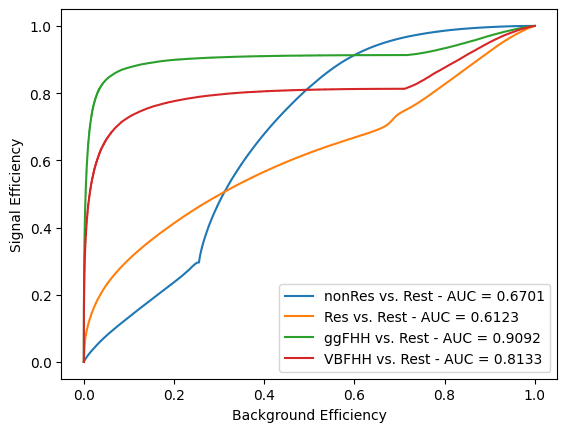

In [4]:
plt.figure(0)
for (fpr, tpr), plot_label in zip(plot_numbers, plot_labels):
    plt.plot(fpr, tpr, label=plot_label)
plt.xlabel('Background Efficiency')
plt.ylabel('Signal Efficiency')
# plt.xscale('log')
plt.legend(loc="lower right")
plt.show()

In [5]:
test_pre = dfdataset.get_all_test(regex='*!Hto2G')
test_pre.columns

Index(['eta', 'lead_eta', 'lead_phi', 'lead_mvaID', 'sublead_eta',
       'sublead_phi', 'sublead_mvaID', 'nonResReg_vbfpair_lead_bjet_eta',
       'nonResReg_vbfpair_lead_bjet_phi',
       'nonResReg_vbfpair_lead_bjet_bTagWPL',
       'nonResReg_vbfpair_lead_bjet_bTagWPM',
       'nonResReg_vbfpair_lead_bjet_bTagWPT',
       'nonResReg_vbfpair_lead_bjet_bTagWPXT',
       'nonResReg_vbfpair_lead_bjet_bTagWPXXT',
       'nonResReg_vbfpair_sublead_bjet_eta',
       'nonResReg_vbfpair_sublead_bjet_phi',
       'nonResReg_vbfpair_sublead_bjet_bTagWPL',
       'nonResReg_vbfpair_sublead_bjet_bTagWPM',
       'nonResReg_vbfpair_sublead_bjet_bTagWPT',
       'nonResReg_vbfpair_sublead_bjet_bTagWPXT',
       'nonResReg_vbfpair_sublead_bjet_bTagWPXXT',
       'nonResReg_vbfpair_DeltaR_j1g1', 'nonResReg_vbfpair_DeltaR_j2g1',
       'nonResReg_vbfpair_DeltaR_j1g2', 'nonResReg_vbfpair_DeltaR_j2g2',
       'nonResReg_vbfpair_DeltaR_jg_min', 'nonResReg_vbfpair_CosThetaStar_CS',
       'nonResReg_vbf

In [6]:
dipho_mass_window = np.logical_and(test_pre['AUX_mass'].gt(100).to_numpy(), test_pre['AUX_mass'].lt(180).to_numpy())
pho_mva_cut = np.logical_and(test_pre['lead_mvaID'].gt(-0.7).to_numpy(), test_pre['sublead_mvaID'].gt(-0.7).to_numpy())
snt_cuts = np.logical_and(dipho_mass_window, pho_mva_cut)

test = test_pre.loc[snt_cuts]

if 'Run3_2025/data' in pd.unique(test['AUX_sample_era']):
    print('upscaling 2024 MC')
    test.loc[test['AUX_sample_era'].eq('Run3_2024/sim'), 'AUX_eventWeight'] = 2 * test.loc[test['AUX_sample_era'].eq('Run3_2024/sim'), 'AUX_eventWeight']
if '' in pd.unique(test['AUX_sample_era']):
    print('upscaling 2022-24 MC')
    for mc_era in ['Run3_2022/sim/preEE', 'Run3_2022/sim/postEE', 'Run3_2023/sim/preBPix', 'Run3_2023/sim/postBPix', 'Run3_2024/sim']:
        test.loc[test['AUX_sample_era'].eq(mc_era), 'AUX_eventWeight'] = 1.8 * test.loc[test['AUX_sample_era'].eq(mc_era), 'AUX_eventWeight']

upscaling 2024 MC
upscaling 2022-24 MC


In [ ]:
oldcats = {
    # 'VBFHH': {
    #     "DVBFHH": 0.774,
    # },
    'cat1': {
        "AUX_DggFHH": 0.20105975753991212,
        "AUX_DnonRes": 0.00033920225777953755,
        "AUX_DRes": 0.5155782175840005
    },
    'cat2': {
        "AUX_DggFHH": 0.8633095100474404,
        "AUX_DnonRes": 0.0015707913189143552,
        "AUX_DRes": 0.7641090808766726
    },
    'cat3': {
        "AUX_DggFHH": 0.7121864823883823,
        "AUX_DnonRes": 0.006492482419944794,
        "AUX_DRes": 0.5593729774038129
    }
}

cats = {
    "cat0": {
        "is_boosted": 1
    },
    "cat1": {
        "is_boosted": 0,
        "DVBFHH": 0.818,  # >
        "dijet_mass": (80, 190)  # 80 < x < 190
    },
    "cat2": {
        "AUX_DggFHH": 0.82294471227980193,  # >
        "AUX_DnonRes": 0.00020721235210142,  # <
        "AUX_DRes": 0.88339185576323398,  # <
        "is_boosted": 0,
        "DVBFHH": 0.818,  # <
        "dijet_mass": (80, 190)  # 80 < x < 190
    },
    "cat3": {
        "AUX_DggFHH": 0.95411234656848931,  # >
        "AUX_DnonRes": 0.57467284921409301,  # <
        "AUX_DRes": 0.00931784785851750,  # <
        "is_boosted": 0,
        "DVBFHH": 0.818,  # <
        "dijet_mass": (80, 190)  # 80 < x < 190
    },
    "cat4" : {
        "AUX_DggFHH": 0.60161934781392234,  # >
        "AUX_DnonRes": 0.00190229357061479,  # <
        "AUX_DRes": 0.80095654321512555,  # <
        "is_boosted": 0,
        "DVBFHH": 0.818,  # <
        "dijet_mass": (80, 190)  # 80 < x < 190
    }
}

In [8]:
#############################################################
# ASCii histogram for rapid plotting
def ascii_hist(x, bins=10, weights=None):
    N,X = np.histogram(x, bins=bins, weights=weights)
    width = 50
    nmax = np.max(N.max())
    for (xi, n) in zip(X,N):
        bar = '#'*int(n*width/nmax)
        xi = '{0: <8.4g}'.format(xi).ljust(10)
        print('{0}| {1}'.format(xi,bar))
def ascii_hist(x, bins=10, weights=None, fit=None):
    N,X = np.histogram(x, bins=bins, weights=weights)
    width = 50
    nmax = np.max([N.max(), fit.max()])
    if fit is None:
        for (xi, n) in zip(X,N):
            bar = '#'*int(n*width/nmax)
            xi = '{0: <8.4g}'.format(xi).ljust(10)
            print('{0}| {1}'.format(xi,bar))
    else:
        for (xi, n, fiti) in zip(X,N,fit):
            bar = '#'*int(n*width/nmax)
            if fiti > n: bar = bar + ' '*(int(fiti*width/nmax) - int(n*width/nmax)) + '+'
            else: bar = ''.join([bar[j] if j != int(fiti*width/nmax) else '+' for j in range(len(bar))])
            xi = '{0: <8.4g}'.format(xi).ljust(10)
            print('{0}| {1}'.format(xi,bar))

#############################################################
# Sideband fit functions for nonRes bkg estimaton
def exp_func(x, a, b):
    return a * np.exp(b * x)
def sd_hist(mass: np.ndarray, weight: np.ndarray, fit_bins: list[float]):
    return hist.Hist(
        hist.axis.Regular(int((fit_bins[1]-fit_bins[0])//fit_bins[2]), fit_bins[0], fit_bins[1], name="var", growth=False, underflow=False, overflow=False), 
        storage='weight'
    ).fill(var=mass, weight=weight)
def exp_mass_fit(mass: np.ndarray, weight: np.ndarray, fit_bins: list[float], sigma: bool=False):
    _hist_ = sd_hist(mass, weight, fit_bins)
    params, _ = curve_fit(
        exp_func, _hist_.axes.centers[0]-_hist_.axes.centers[0][0], _hist_.values(), p0=(_hist_.values()[0], -0.1), 
        sigma=np.where(_hist_.values() != 0, np.sqrt(_hist_.variances()), 0.76) if sigma else None
    )
    print(_hist_)
    ascii_hist(mass, bins=np.arange(fit_bins[0], fit_bins[1], fit_bins[2]), weights=weight, fit=exp_func(_hist_.axes.centers[0]-_hist_.axes.centers[0][0], a=params[0], b=params[1]))
    return _hist_, params
def est_yield(mass: np.ndarray, weight: np.ndarray, fit_bins: list[float], sr_masscut: list[float], sigma: bool=False):
    _hist_, fit_params = exp_mass_fit(mass, weight, fit_bins, sigma=sigma)
    return quad(exp_func, sr_masscut[0]-_hist_.axes.centers[0][0], sr_masscut[1]-_hist_.axes.centers[0][0], args=tuple(fit_params))[0] / fit_bins[2]

In [9]:
data_samples = [sample_name for sample_name in sorted(pd.unique(test['AUX_sample_name']).tolist()) if match_sample(sample_name, ['Data']) is not None]
sideband_samples = [sample_name for sample_name in sorted(pd.unique(test['AUX_sample_name']).tolist()) if match_sample(sample_name, ['GJet', 'TTG']) is not None]
non_sideband_samples = [sample_name for sample_name in sorted(pd.unique(test['AUX_sample_name']).tolist()) if sample_name not in data_samples+sideband_samples]
print(f"All samples: {sorted(pd.unique(test['AUX_sample_name']).tolist())}")
print(f"Data samples: {data_samples}")
print(f"nonRes MC samples: {sideband_samples}")
print(f"Res/Signal MC samples: {non_sideband_samples}")


# field_names = ['Category'] + non_sideband_samples + ['nonRes SB fit', 'data SB fit', 's/b with nonRes fit', 's/b with data fit']
field_names = ['Category'] + non_sideband_samples + ['nonRes SB fit', 'data SB fit']
# field_names = ['Category'] + non_sideband_samples
table = pt.PrettyTable(field_names=field_names, float_format=".3")

not_prev_cut_mask = {}
for name, cuts in cats.items():
    new_row = [name]
    nonRes_sideband = pd.DataFrame({'mass': pd.Series(dtype='float'), 'weight_tot': pd.Series(dtype='float')})

    for sample in non_sideband_samples:

        sample_mask = test['AUX_sample_name'].eq(sample)
        if sample not in not_prev_cut_mask: not_prev_cut_mask[sample] = sample_mask

        pass_cut_mask = not_prev_cut_mask[sample]
        for cut_name, cut in cuts.items():
            pass_cut_mask = np.logical_and(
                pass_cut_mask, test.loc[:, cut_name].gt(cut).to_numpy() if 'HH' in cut_name else test.loc[:, cut_name].lt(cut).to_numpy()
            )
        pass_cut_sr_mask = np.logical_and(
            pass_cut_mask,
            np.logical_and(test.loc[:, 'AUX_mass'].gt(122.5).to_numpy(), test.loc[:, 'AUX_mass'].lt(127.).to_numpy())
        )
        new_row.append(test.loc[pass_cut_sr_mask, 'AUX_eventWeight'].sum())

        not_prev_cut_mask[sample] = np.logical_and(not_prev_cut_mask[sample], ~pass_cut_mask)

    for sb_sample_name, sb_sample_arr in zip(['data', 'nonRes'], [data_samples, sideband_samples]):
        sb_mask = np.zeros(len(test), dtype=bool)
        for sample in sb_sample_arr: sb_mask = np.logical_or(sb_mask, test['AUX_sample_name'].eq(sample))
        if sb_sample_name not in not_prev_cut_mask: not_prev_cut_mask[sb_sample_name] = sb_mask

        pass_cut_mask = not_prev_cut_mask[sb_sample_name]
        for cut_name, cut in cuts.items():
            pass_cut_mask = np.logical_and(
                pass_cut_mask, test.loc[:, cut_name].gt(cut).to_numpy() if 'HH' in cut_name else test.loc[:, cut_name].lt(cut).to_numpy()
            )
        pass_cut_sb_mask = np.logical_and(
            pass_cut_mask,
            np.logical_or(test.loc[:, 'AUX_mass'].lt(120.).to_numpy(), test.loc[:, 'AUX_mass'].gt(130.).to_numpy())
        )
        sb_est_yield = est_yield(test.loc[pass_cut_sb_mask, 'AUX_mass'], test.loc[pass_cut_sb_mask, 'AUX_eventWeight'], [100., 180., 5.], [122.5, 127.])
        new_row.append(sb_est_yield)

    # sum_singleH = new_row[1] + sum(new_row[4:11])
    # new_row.append(new_row[2] / (sum_singleH + new_row[11]))
    # new_row.append(new_row[2] / (sum_singleH + new_row[12]))

    table.add_row(new_row)

print(table)


All samples: ['DDQCDGJets', 'Data', 'GGJets', 'GluGluHToGG', 'GluGluToHH', 'TTGG', 'VBFHH', 'VBFHToGG', 'VHToGG', 'WmHToGG', 'WpHToGG', 'ZHToGG', 'bbHToGG', 'ttHToGG']
Data samples: ['Data']
nonRes MC samples: ['DDQCDGJets', 'GGJets', 'TTGG']
Res/Signal MC samples: ['GluGluHToGG', 'GluGluToHH', 'VBFHH', 'VBFHToGG', 'VHToGG', 'WmHToGG', 'WpHToGG', 'ZHToGG', 'bbHToGG', 'ttHToGG']
             ┌───────────────────────────────────────────────────────────────┐
[100, 105) 4 │██████████████████████████████████████████████████████████████ │
[105, 110) 3 │██████████████████████████████████████████████▌                │
[110, 115) 0 │                                                               │
[115, 120) 2 │███████████████████████████████                                │
[120, 125) 0 │                                                               │
[125, 130) 0 │                                                               │
[130, 135) 3 │██████████████████████████████████████████████▌     

In [10]:
data = test.loc[test['AUX_sample_name'].eq('Data')]
data['CMS_hgg_mass'] = data['AUX_mass']

In [18]:
import uproot

for col, dtype in zip(data.columns, data.dtypes):
    print(f"{col}: {dtype}")

with uproot.recreate('2224_SnT_Data.root') as f:
    f['Data'] = {col: data[col].to_numpy() for col, dtype in zip(data.columns, data.dtypes) if dtype != "str"}

eta: float64
lead_eta: float64
lead_phi: float64
lead_mvaID: float64
sublead_eta: float64
sublead_phi: float64
sublead_mvaID: float64
nonResReg_vbfpair_lead_bjet_eta: float64
nonResReg_vbfpair_lead_bjet_phi: float64
nonResReg_vbfpair_lead_bjet_bTagWPL: float64
nonResReg_vbfpair_lead_bjet_bTagWPM: float64
nonResReg_vbfpair_lead_bjet_bTagWPT: float64
nonResReg_vbfpair_lead_bjet_bTagWPXT: float64
nonResReg_vbfpair_lead_bjet_bTagWPXXT: float64
nonResReg_vbfpair_sublead_bjet_eta: float64
nonResReg_vbfpair_sublead_bjet_phi: float64
nonResReg_vbfpair_sublead_bjet_bTagWPL: float64
nonResReg_vbfpair_sublead_bjet_bTagWPM: float64
nonResReg_vbfpair_sublead_bjet_bTagWPT: float64
nonResReg_vbfpair_sublead_bjet_bTagWPXT: float64
nonResReg_vbfpair_sublead_bjet_bTagWPXXT: float64
nonResReg_vbfpair_DeltaR_j1g1: float64
nonResReg_vbfpair_DeltaR_j2g1: float64
nonResReg_vbfpair_DeltaR_j1g2: float64
nonResReg_vbfpair_DeltaR_j2g2: float64
nonResReg_vbfpair_DeltaR_jg_min: float64
nonResReg_vbfpair_CosThetaSt